In [1]:
import subprocess
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if ((candidate / 'uv.lock').exists() and (candidate / 'implementations').is_dir() and (candidate / 'aieng-forecasting').is_dir()):
            return candidate
    raise FileNotFoundError('Could not find the agentic-forecasting repository root.')

SETUP_ROOT = find_repo_root(Path.cwd().resolve())
print('Running: uv sync --all-extras --dev --all-packages')
setup_result = subprocess.run(['uv', 'sync', '--all-extras', '--dev', '--all-packages'], cwd=SETUP_ROOT, check=False, text=True, capture_output=True)
print(setup_result.stdout)
if setup_result.returncode != 0:
    print(setup_result.stderr)
    raise RuntimeError('uv sync failed. Install uv or restart the notebook with the repository environment selected.')
print('Environment synchronized successfully.')

Running: uv sync --all-extras --dev --all-packages

Environment synchronized successfully.


# Manufacturing Stress Model Comparison

This notebook compares the existing manufacturing-stress forecasting models under one cutoff-aware binary backtest. Numerical models run by default. Analyst-agent and adjusted-hybrid-agent evaluations are explicit opt-ins because they may make LLM calls.

The primary metric is the binary Brier score: lower is better. The 2018-2024 window is a historical diagnostic, not an untouched future holdout.

In [2]:
import json
import os
import sys
from pathlib import Path

for package_root in (SETUP_ROOT / 'aieng-forecasting', SETUP_ROOT / 'implementations'):
    if str(package_root) not in sys.path:
        sys.path.insert(0, str(package_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from aieng.forecasting.evaluation import BacktestSpec, backtest
from aieng.forecasting.methods import HistoricalFrequencyPredictor
from dotenv import load_dotenv
from IPython.display import display
from manufacturing_stress_forecasting.data import build_manufacturing_stress_service
from manufacturing_stress_forecasting.features import FEATURE_SERIES_IDS
from manufacturing_stress_forecasting.predictors import ManufacturingStressLogisticPredictor, ManufacturingStressXGBoostPredictor
from manufacturing_stress_forecasting.run_agent_backtest import run_or_load_backtest, validate_comparable_results

REPO_ROOT = SETUP_ROOT
load_dotenv(REPO_ROOT / '.env', override=False)
SPEC_PATH = REPO_ROOT / 'implementations' / 'manufacturing_stress_forecasting' / 'specs' / 'manufacturing_stress_smoke.yaml'
STORE_DIR = REPO_ROOT / 'data' / 'predictions'
print(f'Repository: {REPO_ROOT}')
print(f'FRED API key loaded: {bool(os.getenv("FRED_API_KEY"))}')

Repository: /home/coder/BMO-C2-agentic-forecasting-1
FRED API key loaded: True


In [ ]:
REFRESH_INPUT_DATA = False
BACKTEST_STRIDE = 3
RUN_ANALYST_AGENT = True
RUN_HYBRID_AGENT = True
FORCE_REFRESH_AGENT_CACHE = False
SHOW_ORIGIN_DETAILS = True
SHOW_PLOTS = True

print({
    'refresh_input_data': REFRESH_INPUT_DATA,
    'backtest_stride': BACKTEST_STRIDE,
    'run_analyst_agent': RUN_ANALYST_AGENT,
    'run_hybrid_agent': RUN_HYBRID_AGENT,
    'force_refresh_agent_cache': FORCE_REFRESH_AGENT_CACHE,
    'show_origin_details': SHOW_ORIGIN_DETAILS,
    'show_plots': SHOW_PLOTS,
})

## Load data and specification

The service is cache-first by default. Set `REFRESH_INPUT_DATA = True` only when intentionally refreshing FRED and Yahoo Finance inputs.

In [4]:
with SPEC_PATH.open() as file:
    base_spec = BacktestSpec.model_validate(yaml.safe_load(file))
spec = base_spec.model_copy(update={'stride': BACKTEST_STRIDE})
service = build_manufacturing_stress_service(cache_dir=REPO_ROOT / 'data' / 'fred', yahoo_cache_dir=REPO_ROOT / 'data' / 'yfinance', refresh=REFRESH_INPUT_DATA)
summary = service.summary()
feature_summary = summary.set_index('series_id')
missing_features = sorted(set(FEATURE_SERIES_IDS) - set(feature_summary.index))
if missing_features:
    raise RuntimeError(f'Missing model features: {missing_features}')
non_monthly_features = [series_id for series_id in FEATURE_SERIES_IDS if feature_summary.loc[series_id, 'frequency'] != 'MS']
if non_monthly_features:
    raise RuntimeError(f'Model features are not monthly: {non_monthly_features}')
print(f'Origins: {spec.start.date()} to {spec.end.date()}, stride={spec.stride}, warmup={spec.warmup}')
print(f'Target: {spec.task.target_series_id}; horizon={spec.task.horizons[0]} {spec.task.frequency}')
print(f'Validated {len(FEATURE_SERIES_IDS)} monthly model features.')

Origins: 2018-01-01 to 2024-12-01, stride=3, warmup=60
Target: manufacturing_stress; horizon=3 MS
Validated 15 monthly model features.


## Run comparable models

The comparison includes historical frequency, fixed logistic regression (`C=0.001`), fixed XGBoost (`50` trees, depth `2`, learning rate `0.03`), and the deterministic hybrid anchor. When enabled, the hybrid agent's bounded adjustment is also evaluated as the final forecast probability. Every result must contain the same scored origin and forecast-date pairs.

In [11]:
from datetime import datetime, timezone

from aieng.forecasting.evaluation.prediction import BinaryForecast, Prediction
from manufacturing_stress_forecasting.hybrid import HybridAgentPredictor, build_hybrid_agent_predictor, build_numerical_anchor

predictor_specs = [
    ('historical_frequency', lambda: HistoricalFrequencyPredictor()),
    ('logistic_c_0_001', lambda: ManufacturingStressLogisticPredictor(regularization_c=0.001)),
    ('xgb_50_depth2_lr0_03', lambda: ManufacturingStressXGBoostPredictor(n_estimators=50, max_depth=2, learning_rate=0.03)),
]
results = {}
for name, factory in predictor_specs:
    predictor = factory()
    result = backtest(predictor=predictor, spec=spec, data_service=service)
    results[name] = result
    print(f'{name}: {result.mean_score:.4f} mean {result.metric}; scored={len(result.scores)} skipped={result.skipped_origins}')

class AnchorPredictor:
    @property
    def predictor_id(self):
        return 'manufacturing_stress_hybrid_anchor_v1'

    def predict(self, task, context):
        anchor = build_numerical_anchor(task, context)
        as_of = pd.Timestamp(context.as_of)
        lead = pd.tseries.frequencies.to_offset(task.frequency) * task.horizons[0]
        return [Prediction(
            predictor_id=self.predictor_id,
            task_id=task.task_id,
            issued_at=datetime.now(tz=timezone.utc).replace(tzinfo=None),
            as_of=context.as_of,
            forecast_date=(as_of + lead).to_pydatetime(),
            payload=BinaryForecast(probability=anchor.probability),
            metadata=anchor.as_dict(),
        )]

anchor_result = backtest(predictor=AnchorPredictor(), spec=spec, data_service=service)
results['hybrid_anchor'] = anchor_result
print(f'hybrid_anchor: {anchor_result.mean_score:.4f} mean {anchor_result.metric}; scored={len(anchor_result.scores)} skipped={anchor_result.skipped_origins}')

if RUN_ANALYST_AGENT:
    from manufacturing_stress_forecasting.analyst_agent import build_manufacturing_stress_agent_predictor

    analyst_predictor = build_manufacturing_stress_agent_predictor(anonymize_dates=True)
    analyst_result = run_or_load_backtest(
        analyst_predictor,
        spec,
        service,
        force_refresh=FORCE_REFRESH_AGENT_CACHE or REFRESH_INPUT_DATA,
        store_dir=STORE_DIR,
    )
    results['analyst_agent'] = analyst_result

if RUN_HYBRID_AGENT:
    hybrid_predictor = HybridAgentPredictor(build_hybrid_agent_predictor(anonymize_dates=True))
    hybrid_result = run_or_load_backtest(
        hybrid_predictor,
        spec,
        service,
        force_refresh=FORCE_REFRESH_AGENT_CACHE or REFRESH_INPUT_DATA,
        store_dir=STORE_DIR,
    )
    results['hybrid_agent_adjusted'] = hybrid_result

validate_comparable_results(list(results.values()))
print('All enabled models were scored on identical forecast origins.')

historical_frequency: 0.0356 mean brier; scored=28 skipped=0
logistic_c_0_001: 0.0380 mean brier; scored=28 skipped=0
xgb_50_depth2_lr0_03: 0.0646 mean brier; scored=28 skipped=0
hybrid_anchor: 0.0480 mean brier; scored=28 skipped=0


Root node manufacturing_stress_analyst was cancelled.
Root node manufacturing_stress_analyst was cancelled.
Root node manufacturing_stress_analyst was cancelled.
Root node manufacturing_stress_analyst was cancelled.
Root node manufacturing_stress_analyst was cancelled.
Root node manufacturing_stress_analyst was cancelled.
Root node manufacturing_stress_analyst was cancelled.
Root node manufacturing_stress_analyst was cancelled.
Root node manufacturing_stress_analyst was cancelled.
Root node manufacturing_stress_analyst was cancelled.
Root node manufacturing_stress_analyst was cancelled.
Root node manufacturing_stress_analyst was cancelled.
Root node manufacturing_stress_analyst was cancelled.
Root node manufacturing_stress_analyst was cancelled.
Root node manufacturing_stress_analyst was cancelled.
Root node manufacturing_stress_analyst was cancelled.
Root node manufacturing_stress_analyst was cancelled.
Root node manufacturing_stress_analyst was cancelled.
Root node manufacturing_stre

agent_predictor_manufacturing_stress_analyst_gemini-3.1-flash-lite-preview_discrete: saved /home/coder/BMO-C2-agentic-forecasting-1/data/predictions/manufacturing_stress_smoke_llmp_v3_090e165add/agent_predictor_manufacturing_stress_analyst_gemini-3.1-flash-lite-preview_discrete.yaml
manufacturing_stress_hybrid_agent_v2: loaded /home/coder/BMO-C2-agentic-forecasting-1/data/predictions/manufacturing_stress_smoke_llmp_v3_090e165add/manufacturing_stress_hybrid_agent_v2.yaml
All enabled models were scored on identical forecast origins.


## Performance plots

These diagnostics show average accuracy, relative skill, temporal stability, and calibration. The primary score remains Brier; ROC-style metrics are intentionally secondary because probability calibration matters.

In [13]:
def result_rows(results):
    baseline = results['historical_frequency'].mean_score
    rows = []
    for name, result in results.items():
        rows.append({
            'model': name,
            'metric': result.metric,
            'mean_brier': result.mean_score,
            'scored_origins': len(result.scores),
            'skipped_origins': result.skipped_origins,
            'delta_vs_baseline': result.mean_score - baseline,
            'brier_skill': 1.0 - result.mean_score / baseline if baseline else np.nan,
        })
    return pd.DataFrame(rows).sort_values('mean_brier').reset_index(drop=True)

comparison = result_rows(results)
display(comparison)

target_values = service.get_series(spec.task.target_series_id, as_of=pd.Timestamp('2100-01-01').to_pydatetime())
outcomes_by_date = {
    pd.Timestamp(timestamp): float(value)
    for timestamp, value in zip(target_values['timestamp'], target_values['value'], strict=True)
}
origin_rows = []
for name, result in results.items():
    for prediction, score in zip(result.predictions, result.scores, strict=True):
        forecast_date = pd.Timestamp(prediction.forecast_date)
        outcome = outcomes_by_date[forecast_date]
        metadata = prediction.metadata or {}
        origin_rows.append({
            'model': name,
            'as_of': prediction.as_of,
            'forecast_date': prediction.forecast_date,
            'anchor_probability': metadata.get('anchor_probability'),
            'agent_probability': metadata.get('agent_probability'),
            'raw_agent_adjustment': metadata.get('raw_agent_adjustment'),
            'agent_adjustment': metadata.get('agent_adjustment'),
            'adjusted_probability': metadata.get('adjusted_probability'),
            'validation_status': metadata.get('validation_status'),
            'rationale': metadata.get('rationale'),
            'probability': float(prediction.payload.probability),
            'outcome': outcome,
            'brier': float(score),
        })
origin_details = pd.DataFrame(origin_rows)
if SHOW_ORIGIN_DETAILS:
    if RUN_HYBRID_AGENT:
        display(origin_details[origin_details['model'] == 'hybrid_agent_adjusted'])
    else:
        display(origin_details.head(20))

,model,metric,mean_brier,scored_origins,skipped_origins,delta_vs_baseline,brier_skill
0,historical_frequency,brier,0.035598,28,0,0.000000,0.000000
1,logistic_c_0_001,brier,0.037981,28,0,0.002383,-0.066930
2,hybrid_anchor,brier,0.048021,28,0,0.012422,-0.348961
3,hybrid_agent_adjusted,brier,0.052184,28,0,0.016585,-0.465906
4,xgb_50_depth2_lr0_03,brier,0.064591,28,0,0.028992,-0.814426
5,analyst_agent,brier,0.075221,28,0,0.039623,-1.113061


,model,as_of,forecast_date,anchor_probability,agent_probability,raw_agent_adjustment,agent_adjustment,adjusted_probability,validation_status,rationale,probability,outcome,brier
140,hybrid_agent_adjusted,2018-01-01,2018-04-01,0.038484,0.0380,-4.837866e-04,-4.837866e-04,0.038000,passed,Manufacturing remains stable with positive thr...,0.038000,0.0,0.001444
141,hybrid_agent_adjusted,2018-04-01,2018-07-01,0.039803,0.0550,1.519702e-02,1.519702e-02,0.055000,passed,"IPMAN remains stable over three months, despit...",0.055000,0.0,0.003025
142,hybrid_agent_adjusted,2018-07-01,2018-10-01,0.038373,0.0380,-3.729703e-04,-3.729703e-04,0.038000,passed,"IPMAN trends remain positive over 1, 3, and 6 ...",0.038000,0.0,0.001444
143,hybrid_agent_adjusted,2018-10-01,2019-01-01,0.036801,0.0368,-9.901781e-07,-9.901781e-07,0.036800,passed,IPMAN trends are positive and stable. Macro in...,0.036800,0.0,0.001354
144,hybrid_agent_adjusted,2019-01-01,2019-04-01,0.056234,0.1200,6.376617e-02,3.000000e-02,0.086234,clamped,"While IPMAN remains stable, significant negati...",0.086234,0.0,0.007436
145,hybrid_agent_adjusted,2019-04-01,2019-07-01,0.058002,0.0850,2.699800e-02,2.699800e-02,0.085000,passed,The 3-month IPMAN decline of -1.69% is approac...,0.085000,0.0,0.007225
146,hybrid_agent_adjusted,2019-07-01,2019-10-01,0.039210,0.0450,5.790336e-03,5.790336e-03,0.045000,passed,Manufacturing shows slight stabilization with ...,0.045000,0.0,0.002025
147,hybrid_agent_adjusted,2019-10-01,2020-01-01,0.042847,0.0550,1.215293e-02,1.215293e-02,0.055000,passed,"IPMAN trends remain weak, showing a slight dec...",0.055000,0.0,0.003025
148,hybrid_agent_adjusted,2020-01-01,2020-04-01,0.034549,0.0345,-4.927178e-05,-4.927178e-05,0.034500,passed,IPMAN shows positive momentum over the last th...,0.034500,1.0,0.932190
149,hybrid_agent_adjusted,2020-04-01,2020-07-01,0.361491,0.6500,2.885093e-01,3.000000e-02,0.391491,clamped,IPMAN has declined significantly (-4.64% over ...,0.391491,0.0,0.153265


Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7cfc4a229c40>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7cfc49f0a900>, 68420.988942855)])']
connector: <aiohttp.connector.TCPConnector object at 0x7cfc4c2c1520>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7cfc49bbd130>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7cfc49c4c210>, 68450.401806707)])']
connector: <aiohttp.connector.TCPConnector object at 0x7cfc49ba39b0>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7cfc49bd5e50>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7cfc49c4c830>, 68479.901253565)])']
connector: <aiohttp.connector.TCPConnector object at 0x7cfc49beb9b0>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7cfc49bcdcd0>
Unclosed connector
connec

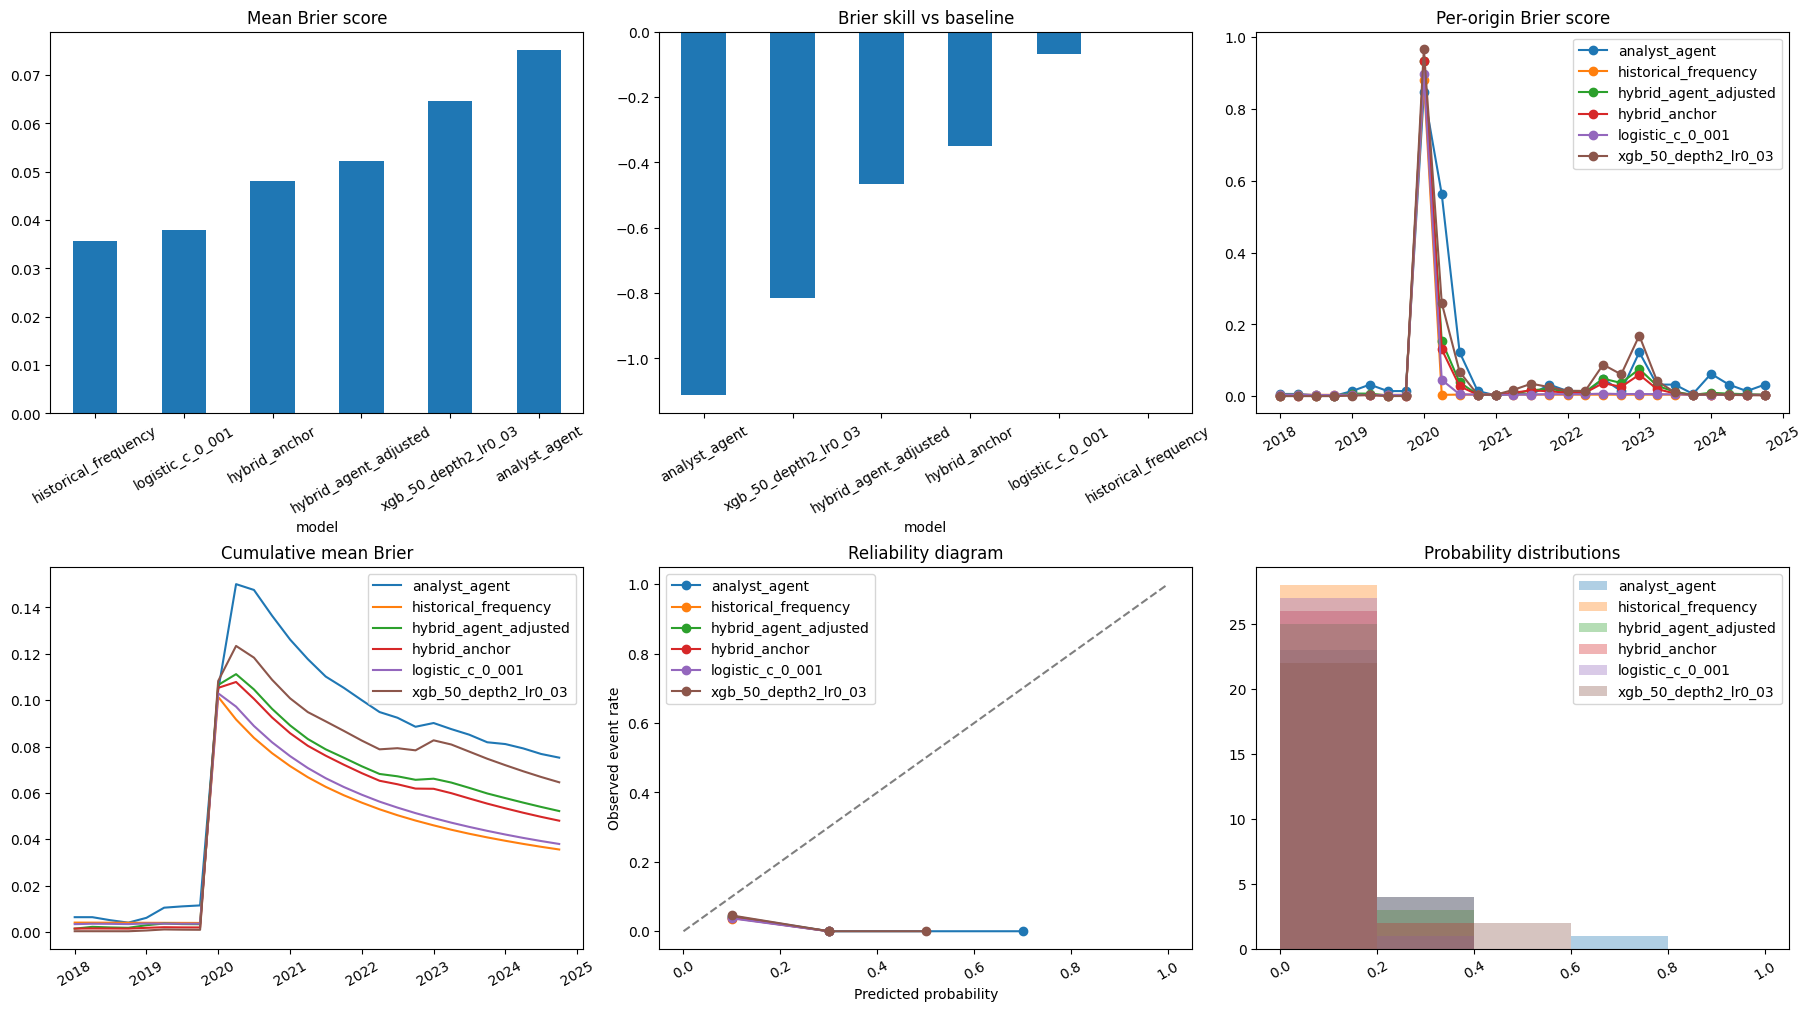

In [14]:
if SHOW_PLOTS:
    plot_data = origin_details.copy()
    plot_data['as_of'] = pd.to_datetime(plot_data['as_of'])
    plot_data['forecast_date'] = pd.to_datetime(plot_data['forecast_date'])
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

    comparison.sort_values('mean_brier').plot.bar(x='model', y='mean_brier', ax=axes[0, 0], legend=False, title='Mean Brier score')
    comparison.sort_values('brier_skill').plot.bar(x='model', y='brier_skill', ax=axes[0, 1], legend=False, title='Brier skill vs baseline')

    for model, group in plot_data.groupby('model'):
        axes[0, 2].plot(group['as_of'], group['brier'], marker='o', label=model)
    axes[0, 2].set_title('Per-origin Brier score')
    axes[0, 2].legend()

    for model, group in plot_data.groupby('model'):
        ordered = group.sort_values('as_of')
        axes[1, 0].plot(ordered['as_of'], ordered['brier'].expanding().mean(), label=model)
    axes[1, 0].set_title('Cumulative mean Brier')
    axes[1, 0].legend()

    bins = np.linspace(0, 1, 6)
    centers = (bins[:-1] + bins[1:]) / 2
    for model, group in plot_data.groupby('model'):
        bucketed = group.assign(probability_bin=pd.cut(group['probability'], bins=bins, labels=False, include_lowest=True))
        calibration = bucketed.dropna(subset=['probability_bin']).groupby('probability_bin', observed=True).agg(
            predicted=('probability', 'mean'), observed=('outcome', 'mean')
        )
        axes[1, 1].plot(calibration.index.map(lambda index: centers[int(index)]), calibration['observed'], marker='o', label=model)
    axes[1, 1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[1, 1].set_title('Reliability diagram')
    axes[1, 1].set_xlabel('Predicted probability')
    axes[1, 1].set_ylabel('Observed event rate')
    axes[1, 1].legend()

    for model, group in plot_data.groupby('model'):
        axes[1, 2].hist(group['probability'], bins=bins, alpha=0.35, label=model)
    axes[1, 2].set_title('Probability distributions')
    axes[1, 2].legend()

    for axis in axes.flat:
        axis.tick_params(axis='x', rotation=30)
    display(fig)
    plt.close(fig)

## Interpretation

A lower Brier score indicates better probabilistic accuracy. Positive Brier skill means improvement over historical frequency. A reliability curve near the diagonal indicates calibration. Large differences between per-origin and cumulative plots indicate regime sensitivity.

The hybrid anchor is derived from logistic and XGBoost and is included as a baseline. When enabled, the hybrid agent's Python-bounded adjustment is incorporated into its forecast probability; the anchor, agent proposal, and applied adjustment remain available as metadata.